# Fig. 2c | Single-motif predicted activation across VMPFC subregions

For each functional motif (**affect / valuation / social**), pool images from the two motif-specific image sets, z-score globally across all (subject x image x region) cells, and plot the across-row mean ± SEM for the three VMPFC subregions (posterior / middle / anterior).

**Expected directional patterns:**
* affect motif (ECED+GAPED, negative images): posterior > middle > anterior
* valuation motif (Food_5k+Food_11, food images): middle > posterior ≈ anterior
* social motif (PISC+Parade, social scenes): anterior > middle > posterior

**Statistics:** Linear mixed-effects (`Activation ~ Region + 0`, Subject as random factor) followed by Tukey HSD pairwise comparison between regions. Results printed to stdout; significance asterisks are not drawn on the bars (add in PPT post-processing).

**Subjects:** 3 NSD subjects (s2, s4, s7), matching the manuscript primary `r > 0.05` encoding-accuracy threshold. The `r > 0.01` sensitivity version uses 6 subjects (data not in this repo).

## 1. Imports and global plot settings

In [1]:
# matplotlib + seaborn-free plotting stack (matches original `1_plot_threshold_0.01.ipynb`).
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# z-score scaler (global, across all images x all regions x all subjects).
from sklearn.preprocessing import StandardScaler, scale

# Linear mixed-effects model for subject-level random effect, then Tukey HSD post-hoc.
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from utils import load_combined_per_subject

# Reproduce the original figure typography: Arial sans-serif, no grid.
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.grid'] = False

# Shared figure-save kwargs: 300 dpi, transparent background, tight bbox.
PLOT_KWARGS = dict(dpi=300, transparent=True, bbox_inches='tight')

# Three available subjects in the repo (manuscript's primary `r > 0.05` analysis).
# The `r > 0.01` sensitivity analysis uses 6 subjects; data not in repo.
SUBJECT_NUM = 3  # s2, s4, s7


## 2. Helper functions: LMM + Tukey, and the single-motif bar plot

In [2]:
def stats_lmm_tukey(df_wide, motif_name):
    """Linear mixed-effects model + Tukey HSD on a stacked wide DataFrame.

    `df_wide` has rows = (subject x image) and columns posterior/middle/anterior.
    We melt into long format (one row per (subject, image, region)), z-score
    activations globally, fit `Activation ~ Region + 0` with Subject as random
    factor, then run Tukey HSD across the three regions.
    """
    n_image = len(df_wide) // SUBJECT_NUM
    df_long = pd.DataFrame({
        'Activation': np.concatenate([
            df_wide['posterior'].values,
            df_wide['middle'].values,
            df_wide['anterior'].values,
        ]),
        'Region': ['posterior'] * len(df_wide) + ['middle'] * len(df_wide) + ['anterior'] * len(df_wide),
        # Subject index repeats for each region; image index nests inside subject.
        'Subject': np.tile(np.repeat(np.arange(SUBJECT_NUM), n_image), 3),
        'ImageID': np.tile(np.tile(np.arange(n_image), SUBJECT_NUM), 3),
    })
    # Global z-score (single Gaussian over the entire long column) to match
    # the original code; preserves between-region relative differences.
    df_long['Activation'] = scale(df_long['Activation'])

    print(f'=== {motif_name}: LMM (Region as fixed, Subject as random) ===')
    # `+ 0` drops the intercept so each Region coefficient is its own mean.
    model = smf.mixedlm('Activation ~ Region + 0', df_long, groups=df_long['Subject'])
    print(model.fit().summary())

    print(f'=== {motif_name}: Tukey HSD pairwise ===')
    print(pairwise_tukeyhsd(endog=df_long['Activation'], groups=df_long['Region']))


def plot_motif(df_wide, color_list, save_stem):
    """Bar plot of (posterior, middle, anterior) for one motif.

    Style choices match the original `1_plot_threshold_0.01.ipynb`:
      * Global z-score via `StandardScaler.fit(flatten)` then column-wise transform.
      * `yerr = .sem()`: standard error of the mean across (subject x image).
      * 3-color palette: brightest hue on the motif-dominant region, others pale.
      * `width=0.5`, `capsize=0`, thin dark error bar (`elinewidth=2`, `#333333`).
      * No legend, no title, no significance asterisks (add in PPT).
    """
    plot_data = df_wide[['posterior', 'middle', 'anterior']].copy()

    # Fit scaler on flattened (n*3,) array, then apply per column. This puts
    # all three regions onto a single z-score scale so bars are comparable.
    scaler = StandardScaler()
    scaler.fit(plot_data.values.flatten().reshape(-1, 1))
    for col in plot_data.columns:
        plot_data[col] = scaler.transform(plot_data[col].values.reshape(-1, 1))

    fig, ax = plt.subplots(figsize=(3, 4), dpi=100)
    ax.bar(
        plot_data.columns,
        plot_data.mean(),
        yerr=plot_data.sem(),           # SEM across all rows (per-region pooled SD / sqrt(n)).
        color=color_list,
        capsize=0,                       # No T-caps on the error bar.
        error_kw={'elinewidth': 2, 'ecolor': '#333333'},
        width=0.5,
    )
    ax.set_ylabel('Activation Score', labelpad=10, color='black')
    fig.tight_layout()
    fig.savefig(f'../plots/{save_stem}.png', **PLOT_KWARGS)
    fig.savefig(f'../plots/{save_stem}.svg', **PLOT_KWARGS)
    plt.show()


## 3. affect motif → posterior dominant

=== emotion: LMM (Region as fixed, Subject as random) ===
           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  Activation
No. Observations:   4635     Method:              REML      
No. Groups:         3        Scale:               0.8293    
Min. group size:    1545     Log-Likelihood:      -6155.4149
Max. group size:    1545     Converged:           Yes       
Mean group size:    1545.0                                  
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Region[anterior]  -0.428    0.199 -2.149 0.032 -0.818 -0.038
Region[middle]     0.156    0.199  0.784 0.433 -0.234  0.546
Region[posterior]  0.272    0.199  1.365 0.172 -0.118  0.662
Group Var          0.117    0.130                           

=== emotion: Tukey HSD pairwise ===


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


...

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


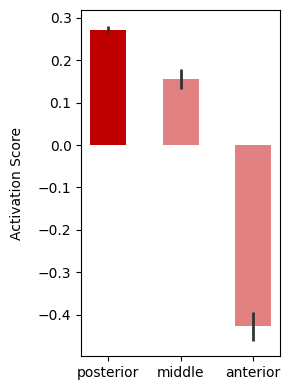

In [3]:
# Two affect image sets from `emotion/` folder:
#   ECED_noneutral: negative-valence emotional pictures with neutral controls removed.
#   GAPED_negative_nonsocial: negative-valence non-social images (animals, threat scenes).
# Both are pooled into one DataFrame so the LMM sees all (subject x image) rows.
df_emotion = load_combined_per_subject('emotion', ['ECED_noneutral', 'GAPED_negative_nonsocial'])

stats_lmm_tukey(df_emotion, 'emotion')

# Palette: posterior = bright red (motif dominant), middle/anterior = pale pink.
plot_motif(df_emotion, ['#c00000', '#e08080', '#e08080'], 'single_emotion')


## 4. valuation motif → middle dominant

=== value: LMM (Region as fixed, Subject as random) ===


           Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  Activation 
No. Observations:  53118    Method:              REML       
No. Groups:        3        Scale:               0.4272     
Min. group size:   17706    Log-Likelihood:      -52804.9598
Max. group size:   17706    Converged:           Yes        
Mean group size:   17706.0                                  
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Region[anterior]  -0.633    0.377 -1.676 0.094 -1.372  0.107
Region[middle]     0.740    0.377  1.961 0.050  0.000  1.480
Region[posterior] -0.107    0.377 -0.284 0.776 -0.847  0.632
Group Var          0.427    0.742                           

=== value: Tukey HSD pairwise ===


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


...

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


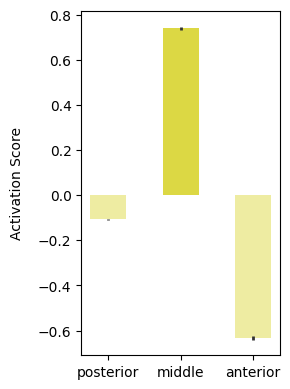

In [4]:
# Two value image sets from `value/` folder:
#   Food_5k: 5k images from Food-101 (everyday foods).
#   Food_11: 11k-image expanded set used in the encoding model.
df_value = load_combined_per_subject('value', ['Food_5k', 'Food_11'])

stats_lmm_tukey(df_value, 'value')

# Palette: middle = bright yellow (motif dominant), posterior/anterior = pale yellow.
plot_motif(df_value, ['#eeeca2', '#dcd844', '#eeeca2'], 'single_value')


## 5. social motif → anterior dominant

=== social: LMM (Region as fixed, Subject as random) ===


/home/opencode/miniconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


...

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


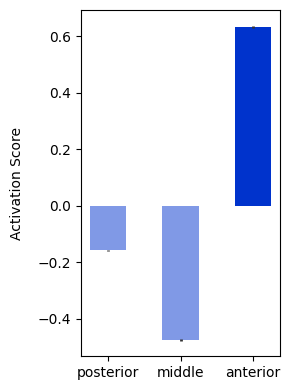

In [5]:
# Two social image sets from `social/` folder:
#   PISC: People in Social Context (~24k images of people interacting).
#   Parade: Multi-person scene photos (parades, group activity).
df_social = load_combined_per_subject('social', ['PISC', 'Parade'])

stats_lmm_tukey(df_social, 'social')

# Palette: anterior = bright blue (motif dominant), posterior/middle = pale blue.
plot_motif(df_social, ['#8099e6', '#8099e6', '#0033cc'], 'single_social')
